# Regresión para estimar la demanda mensual de productos de Ortopedia CEMYDI

**Técnica:** Regresión Ridge  
**Unidad de análisis:** un producto durante un mes  
**Variable objetivo:** `monthly_demand`  
**Semilla:** 42

# 1. Comprensión del negocio

Estimar la demanda mensual de cada producto para compararla con el stock y apoyar la reposición de inventario.

# 2. Comprensión de los datos

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

RANDOM_STATE = 42
RIDGE_ALPHA = 0.8
VALIDATION_MONTHS = 6
ALPHAS_EVALUADOS = [0.1, 0.5, 0.8, 1.0, 5.0, 10.0]

In [2]:
# Carga del dataset
directorio_actual = Path.cwd()

rutas_posibles = [
    directorio_actual / "dataset_demanda_mensual.csv",
    directorio_actual / "../05_Datasets/dataset_demanda_mensual.csv",
    directorio_actual / "05_Datasets/dataset_demanda_mensual.csv",
    Path("/content/dataset_demanda_mensual.csv"),
]

ruta_dataset = next((ruta.resolve() for ruta in rutas_posibles if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError(
        "No se encontró dataset_demanda_mensual.csv. "
        "Colócalo junto a la libreta o en 05_Datasets."
    )

df = pd.read_csv(ruta_dataset)
df["month"] = pd.to_datetime(df["month"], errors="coerce")
df = df.sort_values(["month", "product_id"]).reset_index(drop=True)

print("Archivo:", ruta_dataset)
print("Dimensiones:", df.shape)
df.head()

Archivo: C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\dataset_demanda_mensual.csv
Dimensiones: (1240, 28)


,product_id,product_name,classification,acquisition_type,month,year,month_number,units_sold,units_rented,monthly_demand,completed_sale_orders,valid_rental_requests,average_rental_days,views,searches,add_to_cart,favorites,shares,unit_price,rental_daily_price,stock_at_month_start,active_promotion,requires_prescription,previous_month_sales,previous_month_rentals,previous_month_views,previous_month_demand,average_demand_previous_3_months
0,179,Silla de ruedas estándar,Movilidad,MIXTO,2024-01-01,2024,1,0,0,0,0,0,0.000,0,0,0,0,0,"6,206.170",280.000,24,True,False,0,0,0,0,0.000
1,180,Silla de ruedas reclinable,Movilidad,MIXTO,2024-01-01,2024,1,0,0,0,0,0,0.000,0,0,0,0,0,"10,010.810",420.000,37,False,False,0,0,0,0,0.000
2,181,Silla de ruedas bariátrica,Movilidad,RENTA,2024-01-01,2024,1,0,0,0,0,0,0.000,0,0,0,0,0,"17,342.890",590.000,32,True,False,0,0,0,0,0.000
3,182,Andadera plegable aluminio,Apoyo para caminar,MIXTO,2024-01-01,2024,1,0,0,0,0,0,0.000,0,0,0,0,0,"2,710.260",145.000,28,False,False,0,0,0,0,0.000
4,183,Bastón de cuatro apoyos,Apoyo para caminar,VENTA,2024-01-01,2024,1,0,0,0,0,0,0.000,0,0,0,0,0,"1,262.390",0.000,25,True,False,0,0,0,0,0.000


In [3]:
# Información general
print("Shape:", df.shape)
df.info()

Shape: (1240, 28)
<class 'pandas.DataFrame'>
RangeIndex: 1240 entries, 0 to 1239
Data columns (total 28 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   product_id                        1240 non-null   int64         
 1   product_name                      1240 non-null   str           
 2   classification                    1240 non-null   str           
 3   acquisition_type                  1240 non-null   str           
 4   month                             1240 non-null   datetime64[us]
 5   year                              1240 non-null   int64         
 6   month_number                      1240 non-null   int64         
 7   units_sold                        1240 non-null   int64         
 8   units_rented                      1240 non-null   int64         
 9   monthly_demand                    1240 non-null   int64         
 10  completed_sale_orders             1240 no

In [4]:
# Estadísticas descriptivas
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
product_id,"1,240.000",NaN,NaN,NaN,198.500,179.000,188.750,198.500,208.250,218.000,11.548
product_name,1240,40,Silla de ruedas estándar,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classification,1240,9,Oxigenoterapia,217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
acquisition_type,1240,3,VENTA,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,1240,NaN,NaN,NaN,2025-04-01 08:30:58.064516,2024-01-01 00:00:00,2024-08-01 00:00:00,2025-04-01 00:00:00,2025-12-01 00:00:00,2026-07-01 00:00:00,NaN
year,"1,240.000",NaN,NaN,NaN,"2,024.839","2,024.000","2,024.000","2,025.000","2,025.000","2,026.000",0.766
month_number,"1,240.000",NaN,NaN,NaN,5.935,1.000,3.000,6.000,9.000,12.000,3.351
units_sold,"1,240.000",NaN,NaN,NaN,7.456,0.000,0.000,3.000,11.000,58.000,10.416
units_rented,"1,240.000",NaN,NaN,NaN,0.339,0.000,0.000,0.000,0.000,7.000,0.983
monthly_demand,"1,240.000",NaN,NaN,NaN,7.795,0.000,0.000,3.000,12.000,58.000,10.802


In [5]:
# Valores nulos
nulos = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": (df.isna().mean() * 100).round(2)
})
nulos

,Nulos,Porcentaje
product_id,0,0.000
product_name,0,0.000
classification,0,0.000
acquisition_type,0,0.000
month,0,0.000
year,0,0.000
month_number,0,0.000
units_sold,0,0.000
units_rented,0,0.000
monthly_demand,0,0.000


In [6]:
# Revisión de calidad
columnas_no_negativas = [
    "units_sold", "units_rented", "monthly_demand",
    "completed_sale_orders", "valid_rental_requests",
    "average_rental_days", "views", "searches", "add_to_cart",
    "favorites", "shares", "unit_price", "rental_daily_price",
    "stock_at_month_start", "previous_month_sales",
    "previous_month_rentals", "previous_month_views",
    "previous_month_demand", "average_demand_previous_3_months"
]

meses_totales = df["month"].nunique()
meses_por_producto = df.groupby("product_id")["month"].nunique()

reporte_calidad = pd.DataFrame({
    "Revisión": [
        "Valores nulos",
        "Duplicados exactos",
        "Producto-mes duplicado",
        "Fechas inválidas",
        "Valores negativos",
        "Productos con meses incompletos",
        "Demanda diferente de ventas + rentas",
        "Número de productos",
        "Número de meses"
    ],
    "Resultado": [
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        int(df.duplicated(subset=["product_id", "month"]).sum()),
        int(df["month"].isna().sum()),
        int((df[columnas_no_negativas] < 0).sum().sum()),
        int((meses_por_producto != meses_totales).sum()),
        int((df["monthly_demand"] != df["units_sold"] + df["units_rented"]).sum()),
        int(df["product_id"].nunique()),
        int(meses_totales)
    ]
})
reporte_calidad

,Revisión,Resultado
0,Valores nulos,0
1,Duplicados exactos,0
2,Producto-mes duplicado,0
3,Fechas inválidas,0
4,Valores negativos,0
5,Productos con meses incompletos,0
6,Demanda diferente de ventas + rentas,0
7,Número de productos,40
8,Número de meses,31


In [7]:
# Cantidad de valores únicos y columnas constantes
variabilidad = pd.DataFrame({
    "Columna": df.columns,
    "Valores únicos": [df[col].nunique(dropna=False) for col in df.columns]
}).sort_values("Valores únicos")

variabilidad

,Columna,Valores únicos
21,active_promotion,2
22,requires_prescription,2
3,acquisition_type,3
5,year,3
17,shares,7
16,favorites,8
11,valid_rental_requests,8
8,units_rented,8
24,previous_month_rentals,8
2,classification,9


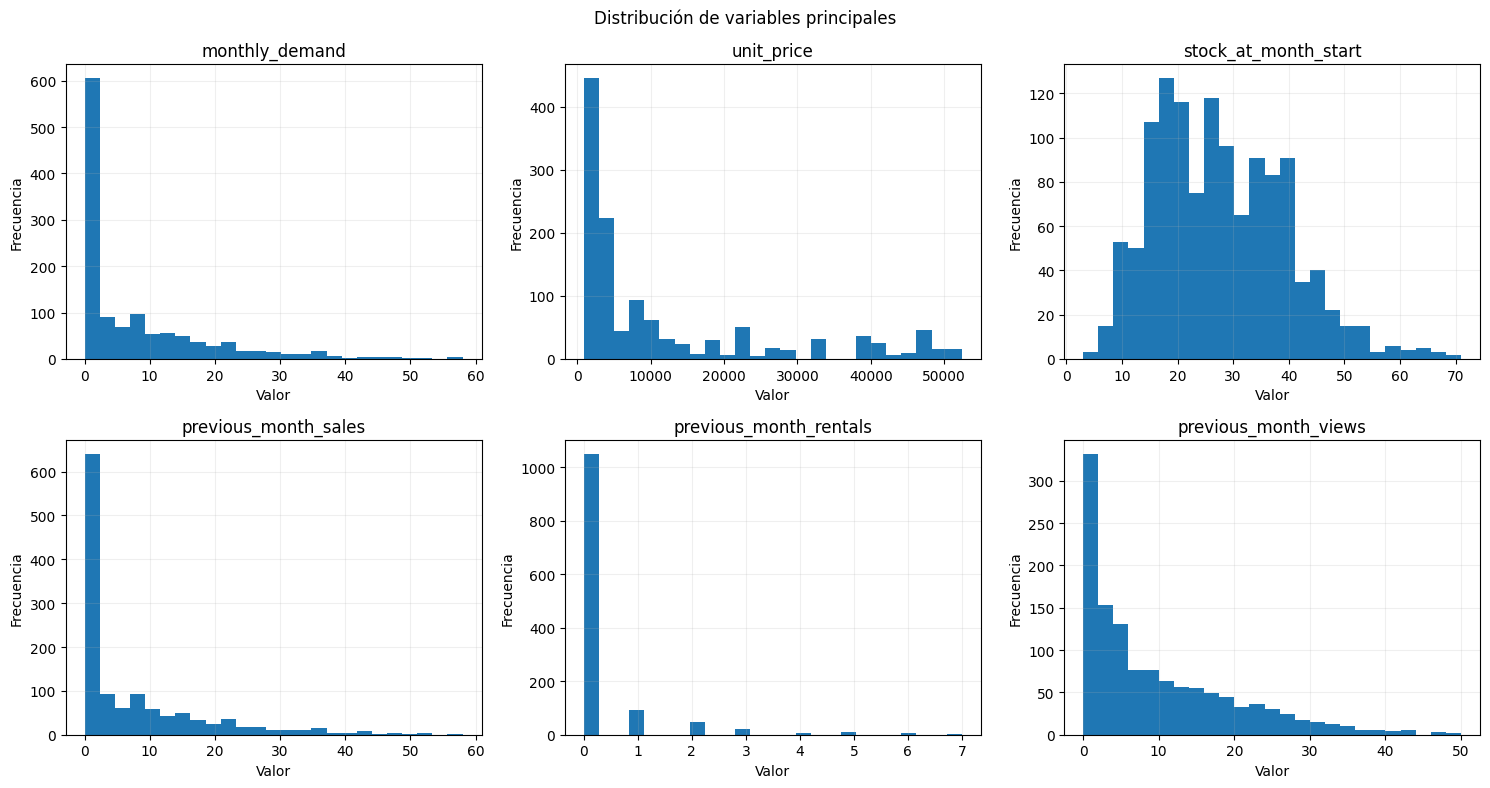

In [8]:
# Distribución de variables numéricas principales
columnas_graficas = [
    "monthly_demand",
    "unit_price",
    "stock_at_month_start",
    "previous_month_sales",
    "previous_month_rentals",
    "previous_month_views"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, columna in zip(axes.ravel(), columnas_graficas):
    ax.hist(df[columna], bins=25)
    ax.set_title(columna)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.grid(alpha=0.2)

plt.suptitle("Distribución de variables principales")
plt.tight_layout()
plt.show()

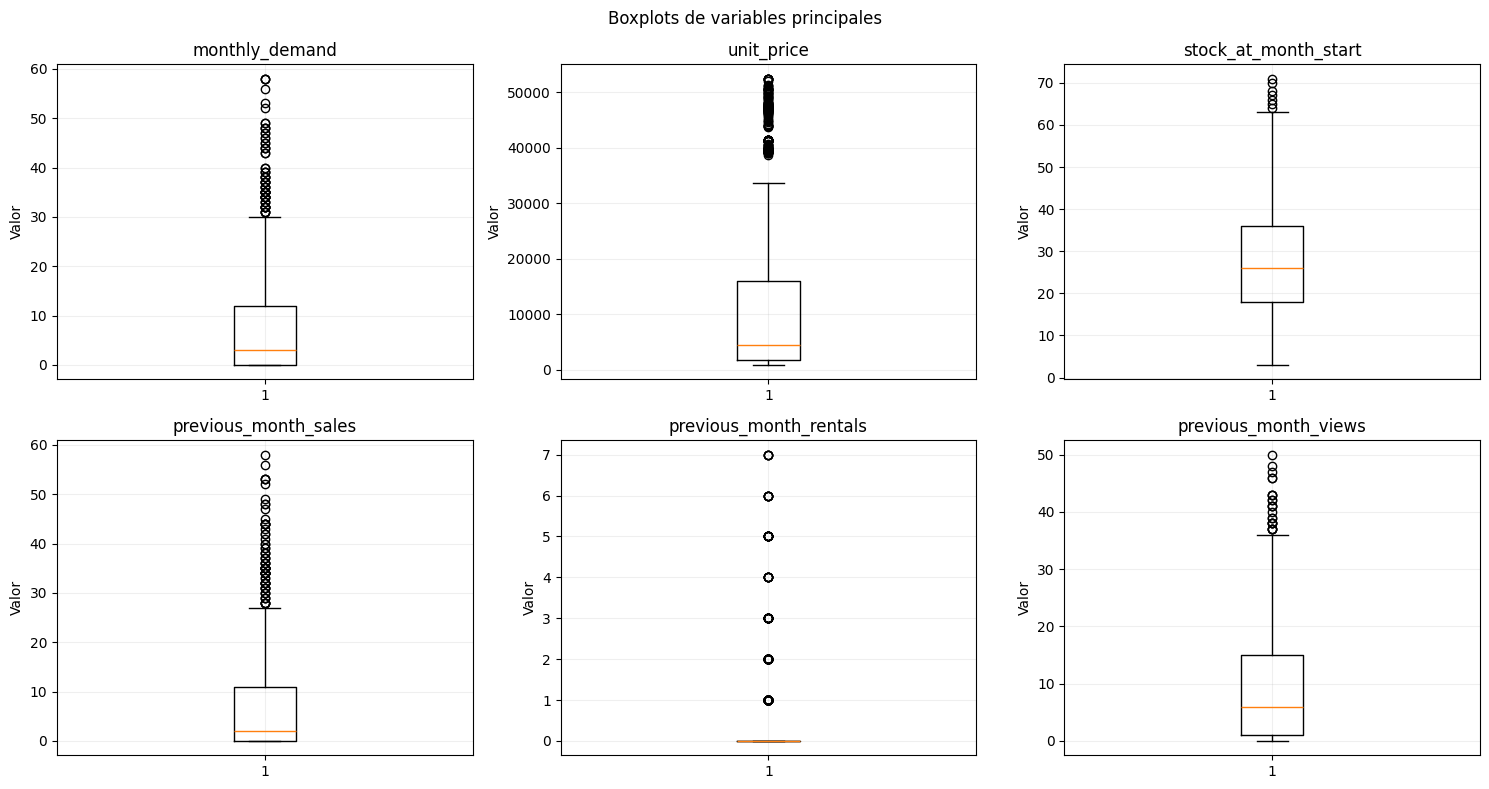

In [9]:
# Boxplots de variables numéricas principales
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, columna in zip(axes.ravel(), columnas_graficas):
    ax.boxplot(df[columna], vert=True)
    ax.set_title(columna)
    ax.set_ylabel("Valor")
    ax.grid(alpha=0.2)

plt.suptitle("Boxplots de variables principales")
plt.tight_layout()
plt.show()

In [10]:
# Demanda igual a cero
cantidad_cero = int((df["monthly_demand"] == 0).sum())
porcentaje_cero = cantidad_cero / len(df) * 100

pd.DataFrame({
    "Indicador": [
        "Registros con demanda igual a cero",
        "Porcentaje con demanda igual a cero",
        "Demanda promedio",
        "Demanda mediana",
        "Demanda máxima"
    ],
    "Resultado": [
        cantidad_cero,
        round(porcentaje_cero, 2),
        round(df["monthly_demand"].mean(), 2),
        round(df["monthly_demand"].median(), 2),
        int(df["monthly_demand"].max())
    ]
})

,Indicador,Resultado
0,Registros con demanda igual a cero,475.000
1,Porcentaje con demanda igual a cero,38.310
2,Demanda promedio,7.800
3,Demanda mediana,3.000
4,Demanda máxima,58.000


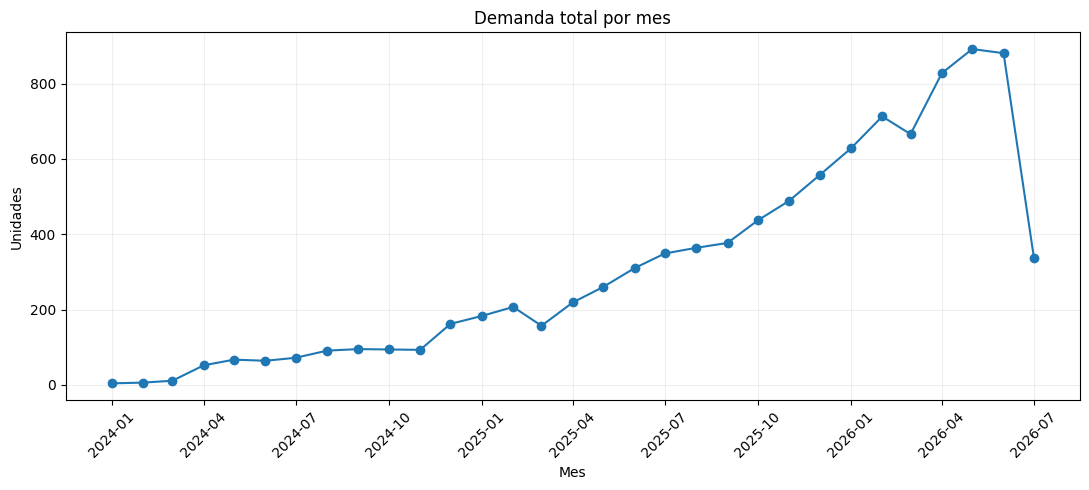

In [11]:
# Evolución mensual de la demanda
demanda_por_mes = (
    df.groupby("month", as_index=False)["monthly_demand"]
      .sum()
)

plt.figure(figsize=(11, 5))
plt.plot(
    demanda_por_mes["month"],
    demanda_por_mes["monthly_demand"],
    marker="o"
)
plt.title("Demanda total por mes")
plt.xlabel("Mes")
plt.ylabel("Unidades")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [12]:
# Correlación con la variable objetivo
correlaciones = (
    df.select_dtypes(include=np.number)
      .corr()["monthly_demand"]
      .sort_values(ascending=False)
      .to_frame("Correlación con monthly_demand")
)
correlaciones

,Correlación con monthly_demand
monthly_demand,1.000
units_sold,0.996
completed_sale_orders,0.974
average_demand_previous_3_months,0.789
previous_month_demand,0.746
previous_month_sales,0.738
year,0.555
views,0.551
previous_month_views,0.521
searches,0.476


# 3. Preparación de los datos

In [13]:
# Variables utilizadas por el modelo
FEATURE_NAMES = [
    "log_unit_price",
    "stock_at_month_start",
    "previous_month_sales",
    "previous_month_rentals",
    "previous_month_views",
    "active_promotion",
    "month_sin",
    "month_cos",
    "requires_prescription",
    "acquisition_renta",
    "acquisition_mixto",
]

def construir_variables(dataframe: pd.DataFrame) -> pd.DataFrame:
    resultado = pd.DataFrame(index=dataframe.index)

    resultado["log_unit_price"] = np.log1p(dataframe["unit_price"])
    resultado["stock_at_month_start"] = dataframe["stock_at_month_start"]
    resultado["previous_month_sales"] = dataframe["previous_month_sales"]
    resultado["previous_month_rentals"] = dataframe["previous_month_rentals"]
    resultado["previous_month_views"] = dataframe["previous_month_views"]
    resultado["active_promotion"] = dataframe["active_promotion"].astype(int)

    angulo = (dataframe["month_number"] / 12) * 2 * np.pi
    resultado["month_sin"] = np.sin(angulo)
    resultado["month_cos"] = np.cos(angulo)

    resultado["requires_prescription"] = (
        dataframe["requires_prescription"].astype(int)
    )
    resultado["acquisition_renta"] = (
        dataframe["acquisition_type"].eq("RENTA").astype(int)
    )
    resultado["acquisition_mixto"] = (
        dataframe["acquisition_type"].eq("MIXTO").astype(int)
    )

    return resultado[FEATURE_NAMES]

X = construir_variables(df)
y = df["monthly_demand"].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
X.head()

Dimensiones de X: (1240, 11)
Dimensiones de y: (1240,)


,log_unit_price,stock_at_month_start,previous_month_sales,previous_month_rentals,previous_month_views,active_promotion,month_sin,month_cos,requires_prescription,acquisition_renta,acquisition_mixto
0,8.733,24,0,0,0,1,0.500,0.866,0,0,1
1,9.212,37,0,0,0,0,0.500,0.866,0,0,1
2,9.761,32,0,0,0,1,0.500,0.866,0,1,0
3,7.905,28,0,0,0,0,0.500,0.866,0,0,1
4,7.142,25,0,0,0,1,0.500,0.866,0,0,0


In [14]:
# Verificación de las variables preparadas
pd.DataFrame({
    "Variable": X.columns,
    "Tipo": [str(X[col].dtype) for col in X.columns],
    "Nulos": [int(X[col].isna().sum()) for col in X.columns],
    "Valores únicos": [int(X[col].nunique()) for col in X.columns]
})

,Variable,Tipo,Nulos,Valores únicos
0,log_unit_price,float64,0,1236
1,stock_at_month_start,int64,0,65
2,previous_month_sales,int64,0,53
3,previous_month_rentals,int64,0,8
4,previous_month_views,int64,0,48
5,active_promotion,int64,0,2
6,month_sin,float64,0,11
7,month_cos,float64,0,11
8,requires_prescription,int64,0,2
9,acquisition_renta,int64,0,2


In [15]:
# División cronológica
meses = np.array(sorted(df["month"].unique()))
meses_validacion = meses[-VALIDATION_MONTHS:]
meses_entrenamiento = meses[:-VALIDATION_MONTHS]

mascara_entrenamiento = df["month"].isin(meses_entrenamiento)
mascara_validacion = df["month"].isin(meses_validacion)

X_train = X.loc[mascara_entrenamiento]
y_train = y.loc[mascara_entrenamiento]
X_validation = X.loc[mascara_validacion]
y_validation = y.loc[mascara_validacion]

df_train = df.loc[mascara_entrenamiento].copy()
df_validation = df.loc[mascara_validacion].copy()

pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Primer mes": [
        df_train["month"].min().strftime("%Y-%m"),
        df_validation["month"].min().strftime("%Y-%m")
    ],
    "Último mes": [
        df_train["month"].max().strftime("%Y-%m"),
        df_validation["month"].max().strftime("%Y-%m")
    ],
    "Meses": [
        df_train["month"].nunique(),
        df_validation["month"].nunique()
    ],
    "Registros": [
        len(df_train),
        len(df_validation)
    ]
})

,Conjunto,Primer mes,Último mes,Meses,Registros
0,Entrenamiento,2024-01,2026-01,25,1000
1,Validación,2026-02,2026-07,6,240


# 4. Modelado

In [16]:
# Línea base: demanda del mes anterior
prediccion_base = df_validation["previous_month_demand"].to_numpy()

metricas_base = {
    "Modelo": "Demanda del mes anterior",
    "R2": r2_score(y_validation, prediccion_base),
    "MAE": mean_absolute_error(y_validation, prediccion_base),
    "RMSE": mean_squared_error(y_validation, prediccion_base) ** 0.5
}

pd.DataFrame([metricas_base]).round(4)

,Modelo,R2,MAE,RMSE
0,Demanda del mes anterior,0.223,9.233,13.515


In [17]:
# Comparación de valores de alpha
resultados_alpha = []
modelos_alpha = {}
predicciones_alpha = {}

for alpha in ALPHAS_EVALUADOS:
    modelo = Pipeline([
        ("escalado", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    modelo.fit(X_train, y_train)
    prediccion = np.maximum(modelo.predict(X_validation), 0)

    modelos_alpha[alpha] = modelo
    predicciones_alpha[alpha] = prediccion

    resultados_alpha.append({
        "alpha": alpha,
        "R2": r2_score(y_validation, prediccion),
        "MAE": mean_absolute_error(y_validation, prediccion),
        "RMSE": mean_squared_error(y_validation, prediccion) ** 0.5
    })

tabla_alpha = pd.DataFrame(resultados_alpha).sort_values(
    "alpha"
).reset_index(drop=True)

tabla_alpha.round(6)

,alpha,R2,MAE,RMSE
0,0.100,0.432,8.770,11.561
1,0.500,0.432,8.770,11.561
2,0.800,0.432,8.770,11.561
3,1.000,0.432,8.770,11.561
4,5.000,0.432,8.772,11.560
5,10.000,0.432,8.774,11.559


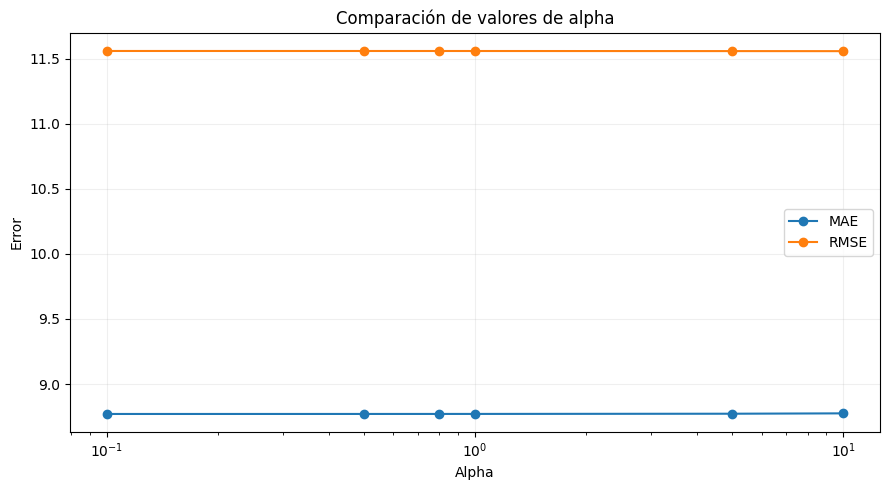

In [18]:
# Visualización de la comparación de alpha
plt.figure(figsize=(9, 5))
plt.plot(tabla_alpha["alpha"], tabla_alpha["MAE"], marker="o", label="MAE")
plt.plot(tabla_alpha["alpha"], tabla_alpha["RMSE"], marker="o", label="RMSE")
plt.title("Comparación de valores de alpha")
plt.xlabel("Alpha")
plt.ylabel("Error")
plt.xscale("log")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [19]:
# Modelo Ridge integrado
modelo_evaluacion = modelos_alpha[RIDGE_ALPHA]
prediccion_validacion = predicciones_alpha[RIDGE_ALPHA]

print(f"Modelo seleccionado: Ridge alpha={RIDGE_ALPHA}")

Modelo seleccionado: Ridge alpha=0.8


# 5. Evaluación

In [20]:
# Métricas generales
metricas_ridge = {
    "Modelo": f"Ridge alpha={RIDGE_ALPHA}",
    "R2": r2_score(y_validation, prediccion_validacion),
    "MAE": mean_absolute_error(y_validation, prediccion_validacion),
    "RMSE": mean_squared_error(
        y_validation,
        prediccion_validacion
    ) ** 0.5
}

comparacion_modelos = pd.DataFrame([
    metricas_base,
    metricas_ridge
])

comparacion_modelos.round(4)

,Modelo,R2,MAE,RMSE
0,Demanda del mes anterior,0.223,9.233,13.515
1,Ridge alpha=0.8,0.432,8.770,11.561


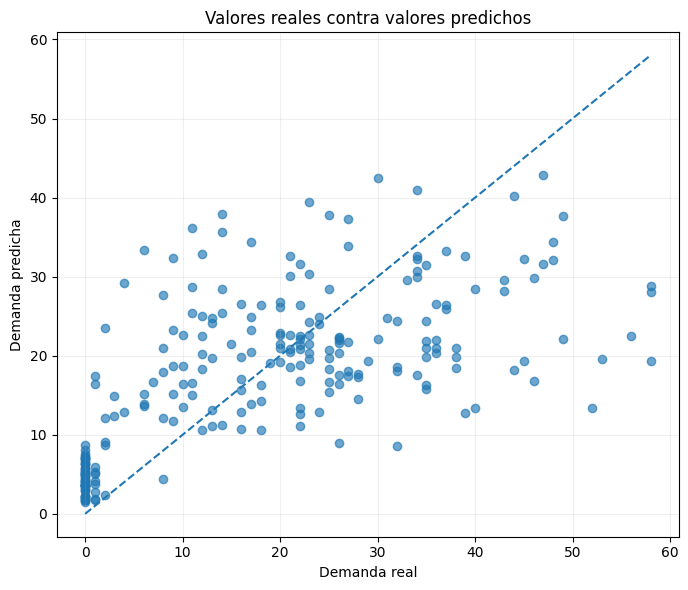

In [21]:
# Valores reales contra predichos
limite_grafica = max(
    float(y_validation.max()),
    float(prediccion_validacion.max())
)

plt.figure(figsize=(7, 6))
plt.scatter(y_validation, prediccion_validacion, alpha=0.65)
plt.plot(
    [0, limite_grafica],
    [0, limite_grafica],
    linestyle="--"
)
plt.title("Valores reales contra valores predichos")
plt.xlabel("Demanda real")
plt.ylabel("Demanda predicha")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

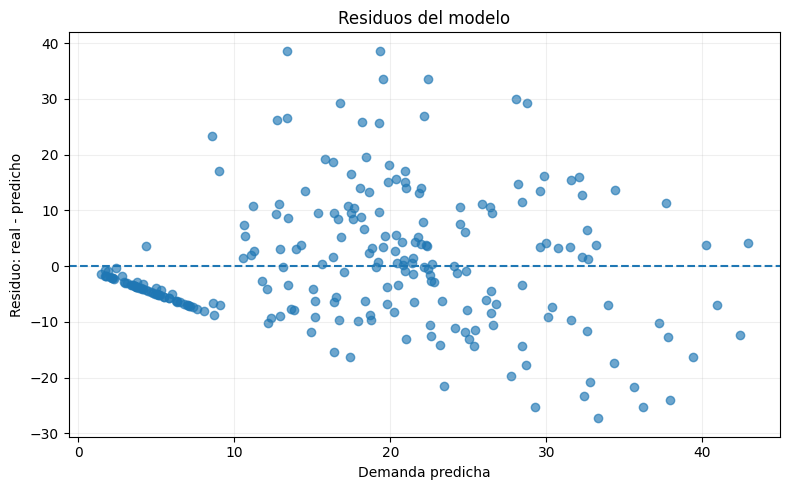

,Residuos
count,240.000
mean,0.311
std,11.581
min,-27.314
25%,-6.677
50%,-2.081
75%,6.249
max,38.638


In [22]:
# Residuos
residuos = y_validation.to_numpy() - prediccion_validacion

plt.figure(figsize=(8, 5))
plt.scatter(prediccion_validacion, residuos, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.title("Residuos del modelo")
plt.xlabel("Demanda predicha")
plt.ylabel("Residuo: real - predicho")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

pd.Series(residuos, name="Residuos").describe().to_frame().round(3)

In [23]:
# Métricas por mes
evaluacion_detalle = df_validation[
    ["product_id", "product_name", "month", "monthly_demand"]
].copy()

evaluacion_detalle["predicted_demand"] = prediccion_validacion
evaluacion_detalle["residual"] = (
    evaluacion_detalle["monthly_demand"]
    - evaluacion_detalle["predicted_demand"]
)
evaluacion_detalle["absolute_error"] = evaluacion_detalle["residual"].abs()

resultados_mensuales = []

for mes, grupo in evaluacion_detalle.groupby("month"):
    resultados_mensuales.append({
        "month": mes,
        "Mes": mes.strftime("%Y-%m"),
        "R2": r2_score(
            grupo["monthly_demand"],
            grupo["predicted_demand"]
        ),
        "MAE": mean_absolute_error(
            grupo["monthly_demand"],
            grupo["predicted_demand"]
        ),
        "RMSE": mean_squared_error(
            grupo["monthly_demand"],
            grupo["predicted_demand"]
        ) ** 0.5
    })

metricas_por_mes = pd.DataFrame(resultados_mensuales)
metricas_por_mes[["Mes", "R2", "MAE", "RMSE"]].round(3)

,Mes,R2,MAE,RMSE
0,2026-02,0.523,6.913,9.052
1,2026-03,0.553,6.164,8.472
2,2026-04,0.499,8.945,11.688
3,2026-05,0.389,10.374,14.766
4,2026-06,0.536,9.453,11.027
5,2026-07,-2.332,10.770,13.112


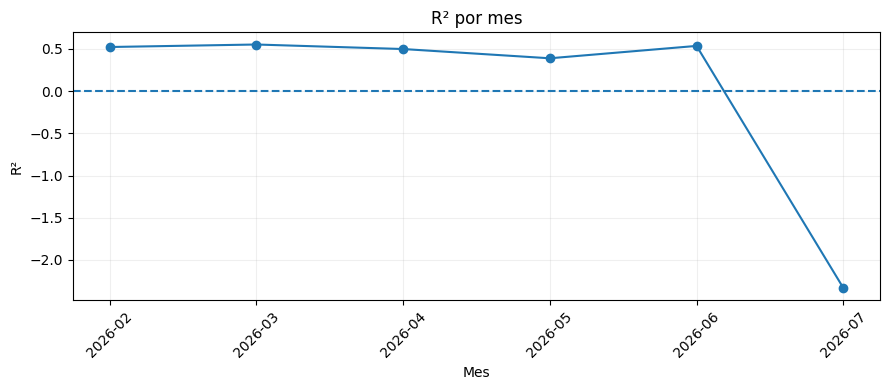

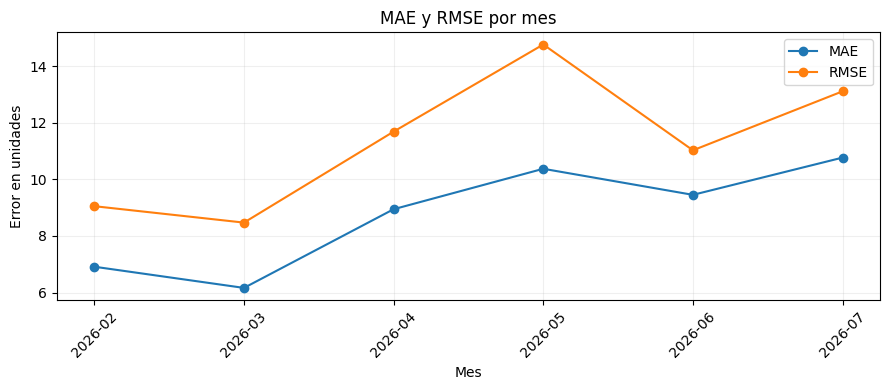

In [24]:
# Gráficas de métricas por mes
plt.figure(figsize=(9, 4))
plt.plot(metricas_por_mes["Mes"], metricas_por_mes["R2"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("R² por mes")
plt.xlabel("Mes")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(metricas_por_mes["Mes"], metricas_por_mes["MAE"], marker="o", label="MAE")
plt.plot(metricas_por_mes["Mes"], metricas_por_mes["RMSE"], marker="o", label="RMSE")
plt.title("MAE y RMSE por mes")
plt.xlabel("Mes")
plt.ylabel("Error en unidades")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [25]:
# Casos con mayor error
mayores_errores = (
    evaluacion_detalle
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

mayores_errores.round(2)

C:\Users\Victo\AppData\Local\Temp\ipykernel_29628\2016387997.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  mayores_errores.round(2)


,product_id,product_name,month,monthly_demand,predicted_demand,residual,absolute_error
1151,210,Barandal abatible para cama,2026-05-01,52,13.360,38.640,38.640
1154,213,Silla cómoda sanitaria,2026-05-01,58,19.360,38.640,38.640
1135,194,Banco para regadera,2026-05-01,56,22.440,33.560,33.560
1129,188,Nebulizador compresor,2026-05-01,53,19.520,33.480,33.480
1102,201,Andadera pediátrica ajustable,2026-04-01,58,28.040,29.960,29.960
1123,182,Andadera plegable aluminio,2026-05-01,58,28.770,29.230,29.230
1080,179,Silla de ruedas estándar,2026-04-01,46,16.800,29.200,29.200
1204,183,Bastón de cuatro apoyos,2026-07-01,6,33.310,-27.310,27.310
1119,218,Compresero eléctrico terapéutico,2026-04-01,49,22.150,26.850,26.850
1012,191,Colchón antiescaras,2026-02-01,40,13.350,26.650,26.650


# 6. Despliegue

In [26]:
# Pipeline final y pronóstico del siguiente mes
modelo_final = Pipeline([
    ("escalado", StandardScaler()),
    ("ridge", Ridge(alpha=RIDGE_ALPHA))
])

modelo_final.fit(X, y)

ultimo_mes = df["month"].max()
mes_pronosticado = ultimo_mes + pd.offsets.MonthBegin(1)

entrada_futura = df[df["month"] == ultimo_mes].copy()

entrada_futura["previous_month_sales"] = entrada_futura["units_sold"]
entrada_futura["previous_month_rentals"] = entrada_futura["units_rented"]
entrada_futura["previous_month_views"] = entrada_futura["views"]
entrada_futura["month"] = mes_pronosticado
entrada_futura["year"] = mes_pronosticado.year
entrada_futura["month_number"] = mes_pronosticado.month

# Para la demostración reproducible no se programa una promoción futura.
# En el sistema real este valor debe consultarse desde PostgreSQL.
entrada_futura["active_promotion"] = False

X_futuro = construir_variables(entrada_futura)

prediccion_futura_decimal = np.maximum(
    modelo_final.predict(X_futuro),
    0
)
prediccion_futura_interfaz = np.rint(
    prediccion_futura_decimal
).astype(int)

pronostico = entrada_futura[
    [
        "product_id",
        "product_name",
        "classification",
        "acquisition_type",
        "unit_price",
        "stock_at_month_start",
        "previous_month_sales",
        "previous_month_rentals",
        "previous_month_views",
        "active_promotion"
    ]
].copy()

pronostico["forecast_month"] = mes_pronosticado.strftime("%Y-%m")
pronostico["predicted_demand_decimal"] = prediccion_futura_decimal
pronostico["predicted_demand_interface"] = prediccion_futura_interfaz
pronostico["shortage"] = (
    pronostico["predicted_demand_interface"]
    - pronostico["stock_at_month_start"]
)

def accion_reposicion(diferencia: int) -> str:
    if diferencia >= 10:
        return f"Priorizar la reposición de {diferencia} unidades."
    if diferencia > 0:
        return f"Programar una compra preventiva de {diferencia} unidades."
    if diferencia == 0:
        return "Monitorear la rotación antes de reponer."
    return "Mantener el inventario y revisar la rotación mensual."

pronostico["suggested_action"] = (
    pronostico["shortage"]
    .astype(int)
    .map(accion_reposicion)
)

pronostico = pronostico.sort_values(
    "predicted_demand_interface",
    ascending=False
).reset_index(drop=True)

print("Último mes histórico:", ultimo_mes.strftime("%Y-%m"))
print("Mes pronosticado:", mes_pronosticado.strftime("%Y-%m"))
print("Productos pronosticados:", len(pronostico))

pronostico.head(10)

Último mes histórico: 2026-07
Mes pronosticado: 2026-08
Productos pronosticados: 40


,product_id,product_name,classification,acquisition_type,unit_price,stock_at_month_start,previous_month_sales,previous_month_rentals,previous_month_views,active_promotion,forecast_month,predicted_demand_decimal,predicted_demand_interface,shortage,suggested_action
0,195,Faja lumbar ortopédica,Ortesis,VENTA,"1,558.460",30,22,0,7,False,2026-08,15.020,15,-15,Mantener el inventario y revisar la rotación mensual.
1,194,Banco para regadera,Baño y seguridad,VENTA,"1,950.510",10,20,0,9,False,2026-08,15.229,15,5,Programar una compra preventiva de 5 unidades.
2,188,Nebulizador compresor,Oxigenoterapia,VENTA,"1,807.250",68,26,0,4,False,2026-08,14.458,14,-54,Mantener el inventario y revisar la rotación mensual.
3,182,Andadera plegable aluminio,Apoyo para caminar,MIXTO,"2,781.540",39,19,1,1,False,2026-08,12.421,12,-27,Mantener el inventario y revisar la rotación mensual.
4,193,Baño portátil con ruedas,Baño y seguridad,MIXTO,"5,203.970",28,9,3,8,False,2026-08,11.613,12,-16,Mantener el inventario y revisar la rotación mensual.
5,184,Muletas axilares ajustables,Apoyo para caminar,MIXTO,"1,719.870",71,11,3,11,False,2026-08,11.901,12,-59,Mantener el inventario y revisar la rotación mensual.
6,218,Compresero eléctrico terapéutico,Rehabilitación,VENTA,"2,993.120",51,17,0,12,False,2026-08,11.756,12,-39,Mantener el inventario y revisar la rotación mensual.
7,213,Silla cómoda sanitaria,Baño y seguridad,MIXTO,"3,697.510",41,8,3,15,False,2026-08,12.096,12,-29,Mantener el inventario y revisar la rotación mensual.
8,211,Cojín antiescaras de gel,Cuidado en casa,VENTA,"4,180.330",16,14,0,8,False,2026-08,10.891,11,-5,Mantener el inventario y revisar la rotación mensual.
9,203,Oxímetro de pulso digital,Oxigenoterapia,VENTA,"1,369.820",33,13,0,11,False,2026-08,10.927,11,-22,Mantener el inventario y revisar la rotación mensual.


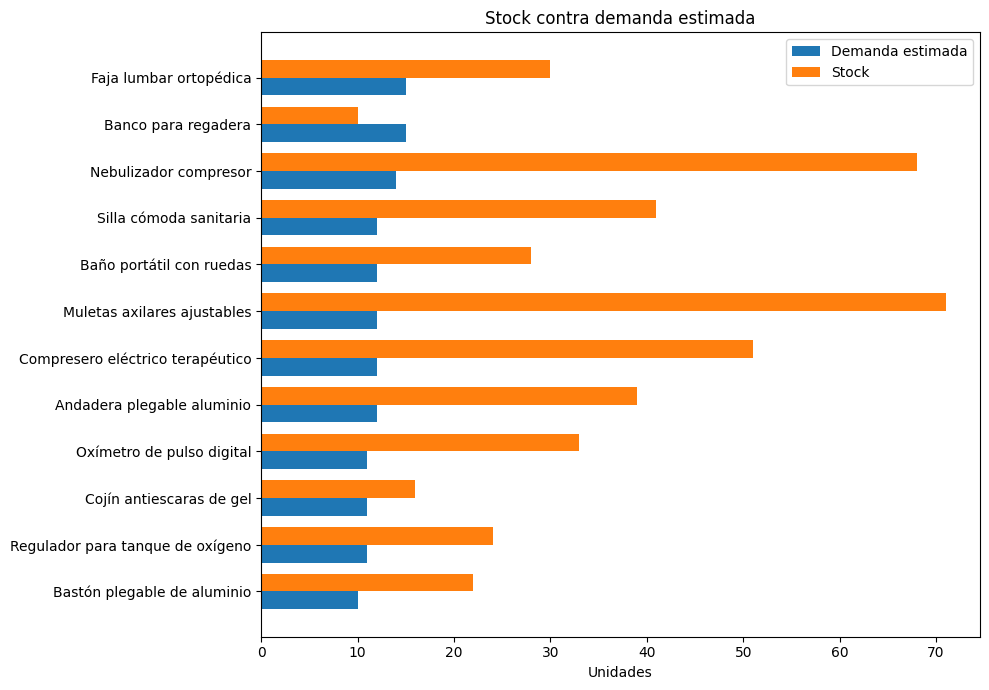

In [27]:
# Stock contra demanda estimada
principales = pronostico.head(12).sort_values(
    "predicted_demand_interface",
    ascending=True
)

posiciones = np.arange(len(principales))
ancho = 0.38

plt.figure(figsize=(10, 7))
plt.barh(
    posiciones - ancho / 2,
    principales["predicted_demand_interface"],
    height=ancho,
    label="Demanda estimada"
)
plt.barh(
    posiciones + ancho / 2,
    principales["stock_at_month_start"],
    height=ancho,
    label="Stock"
)
plt.yticks(posiciones, principales["product_name"])
plt.title("Stock contra demanda estimada")
plt.xlabel("Unidades")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# Dos casos para evidencia del sistema
caso_faltante = (
    pronostico[pronostico["shortage"] > 0]
    .sort_values("shortage", ascending=False)
    .head(1)
)

caso_stock_suficiente = (
    pronostico[pronostico["shortage"] <= 0]
    .sort_values("shortage")
    .head(1)
)

casos_evidencia = pd.concat([
    caso_faltante.assign(tipo_caso="Posible faltante"),
    caso_stock_suficiente.assign(tipo_caso="Stock suficiente")
])

columnas_evidencia = [
    "tipo_caso",
    "product_id",
    "product_name",
    "forecast_month",
    "predicted_demand_interface",
    "stock_at_month_start",
    "shortage",
    "suggested_action"
]

casos_evidencia[columnas_evidencia]

,tipo_caso,product_id,product_name,forecast_month,predicted_demand_interface,stock_at_month_start,shortage,suggested_action
1,Posible faltante,194,Banco para regadera,2026-08,15,10,5,Programar una compra preventiva de 5 unidades.
18,Stock suficiente,214,Barra de apoyo para baño,2026-08,7,70,-63,Mantener el inventario y revisar la rotación mensual.


In [29]:
# Generación de artefactos
if directorio_actual.name == "06_Notebooks":
    raiz_proyecto = directorio_actual.parent
else:
    raiz_proyecto = directorio_actual

carpeta_modelos = raiz_proyecto / "07_Modelos" / "regresion"
carpeta_modelos.mkdir(parents=True, exist_ok=True)

ruta_pipeline = carpeta_modelos / "ridge_demanda_pipeline.joblib"
ruta_modelo_json = carpeta_modelos / "ridge_demanda_modelo.json"
ruta_metricas = carpeta_modelos / "metricas_regresion.json"
ruta_validacion = carpeta_modelos / "predicciones_validacion.csv"
ruta_pronostico = carpeta_modelos / "pronostico_siguiente_mes.csv"
ruta_metadata = carpeta_modelos / "metadata_regresion.json"

joblib.dump(modelo_final, ruta_pipeline)

scaler_final = modelo_final.named_steps["escalado"]
ridge_final = modelo_final.named_steps["ridge"]

modelo_json = {
    "model_type": "Ridge",
    "alpha": RIDGE_ALPHA,
    "feature_names": FEATURE_NAMES,
    "scaler_mean": scaler_final.mean_.tolist(),
    "scaler_scale": scaler_final.scale_.tolist(),
    "coefficients": ridge_final.coef_.tolist(),
    "intercept": float(ridge_final.intercept_),
    "clip_min": 0,
    "round_only_for_interface": True
}

ruta_modelo_json.write_text(
    json.dumps(modelo_json, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

metricas_json = {
    "training_period": {
        "from": df_train["month"].min().strftime("%Y-%m"),
        "to": df_train["month"].max().strftime("%Y-%m"),
        "rows": int(len(df_train))
    },
    "validation_period": {
        "from": df_validation["month"].min().strftime("%Y-%m"),
        "to": df_validation["month"].max().strftime("%Y-%m"),
        "rows": int(len(df_validation))
    },
    "baseline": {
        "r2": float(metricas_base["R2"]),
        "mae": float(metricas_base["MAE"]),
        "rmse": float(metricas_base["RMSE"])
    },
    "ridge": {
        "alpha": RIDGE_ALPHA,
        "r2": float(metricas_ridge["R2"]),
        "mae": float(metricas_ridge["MAE"]),
        "rmse": float(metricas_ridge["RMSE"])
    },
    "alpha_comparison": json.loads(
        tabla_alpha.to_json(orient="records")
    )
}

ruta_metricas.write_text(
    json.dumps(metricas_json, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

evaluacion_detalle.to_csv(
    ruta_validacion,
    index=False,
    encoding="utf-8"
)

pronostico.to_csv(
    ruta_pronostico,
    index=False,
    encoding="utf-8"
)

metadata = {
    "name": "Predicción mensual de demanda CEMYDI",
    "version": "1.0",
    "algorithm": "Ridge",
    "alpha": RIDGE_ALPHA,
    "target": "monthly_demand",
    "target_definition": "units_sold + units_rented",
    "features": FEATURE_NAMES,
    "historical_from": df["month"].min().strftime("%Y-%m"),
    "historical_through": df["month"].max().strftime("%Y-%m"),
    "historical_months": int(df["month"].nunique()),
    "products": int(df["product_id"].nunique()),
    "historical_rows": int(len(df)),
    "forecast_month": mes_pronosticado.strftime("%Y-%m"),
    "prediction_rule": "maximum(raw_prediction, 0)",
    "data_type": "100 % sintético"
}

ruta_metadata.write_text(
    json.dumps(metadata, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

print("Archivos generados:")
for ruta in [
    ruta_pipeline,
    ruta_modelo_json,
    ruta_metricas,
    ruta_validacion,
    ruta_pronostico,
    ruta_metadata
]:
    print("-", ruta)

Archivos generados:
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\ridge_demanda_pipeline.joblib
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\ridge_demanda_modelo.json
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\metricas_regresion.json
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\predicciones_validacion.csv
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\pronostico_siguiente_mes.csv
- C:\Users\Victo\Documents\ortopedia-cemydi-web\cemydi-backend\modelos_propuestos\CEMYDI_Regresion_CRISP_DM\07_Modelos\regresion\metadata_regresion.json


In [30]:
# Verificación de los artefactos
pipeline_cargado = joblib.load(ruta_pipeline)
artefacto_json = json.loads(
    ruta_modelo_json.read_text(encoding="utf-8")
)

muestra_verificacion = X_futuro.head(5).copy()

pred_original = np.maximum(
    modelo_final.predict(muestra_verificacion),
    0
)
pred_cargada = np.maximum(
    pipeline_cargado.predict(muestra_verificacion),
    0
)

media_json = np.asarray(artefacto_json["scaler_mean"], dtype=float)
escala_json = np.asarray(artefacto_json["scaler_scale"], dtype=float)
coef_json = np.asarray(artefacto_json["coefficients"], dtype=float)
intercepto_json = float(artefacto_json["intercept"])

X_json = muestra_verificacion[
    artefacto_json["feature_names"]
].to_numpy(dtype=float)

X_json_escalado = (X_json - media_json) / escala_json

pred_json = np.maximum(
    intercepto_json + X_json_escalado @ coef_json,
    0
)

verificacion = pd.DataFrame({
    "product_name": entrada_futura.head(5)["product_name"].to_numpy(),
    "pipeline_original": pred_original,
    "pipeline_cargado": pred_cargada,
    "formula_json": pred_json,
    "diferencia_pipeline": np.abs(pred_original - pred_cargada),
    "diferencia_json": np.abs(pred_original - pred_json)
})

assert np.allclose(pred_original, pred_cargada, atol=1e-10)
assert np.allclose(pred_original, pred_json, atol=1e-10)

verificacion

,product_name,pipeline_original,pipeline_cargado,formula_json,diferencia_pipeline,diferencia_json
0,Silla de ruedas estándar,9.465,9.465,9.465,0.000,0.000
1,Silla de ruedas reclinable,1.019,1.019,1.019,0.000,0.000
2,Silla de ruedas bariátrica,0.000,0.000,0.000,0.000,0.000
3,Andadera plegable aluminio,12.421,12.421,12.421,0.000,0.000
4,Bastón de cuatro apoyos,5.353,5.353,5.353,0.000,0.000


# Conclusión breve

El modelo Ridge se evaluó con separación cronológica, se comparó contra la demanda del mes anterior y generó los artefactos utilizados para pronosticar el siguiente mes.